In [29]:
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, GRU
import rnn_model
import stocks
import tensorflow_addons as tfa
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Reading & Preprocessing data.
train_data, test_data = stocks.read_data(preprocessing=True, scaling_method='MinMax')

scaler = MinMaxScaler(feature_range=(0, 1))
# Creating time frames.
x_train, y_train = stocks.construct_time_frames(train_data, frame_size=64)
x_test, y_test = stocks.construct_time_frames(test_data, frame_size=64)
min = np.min(y_test)
max = np.max(y_test)

# Defining layers of LSTM.
print("xtrain shape ",x_train.shape[1:])
input_shape = x_train.shape[1:]

20 data train pertama: 
         Date  Open  High  Low  Close Adj Close     Volume
0   09/03/23   342   342  330    342    24.82%   52800000
1   10/03/23   424   426  320    426    24.56%  677310000
2   13/03/23   440   530  412    530    24.41%  179130000
3   14/03/23   550   660  550    660    24.53%  312780000
4   15/03/23   710   825  700    825    25.00%  161470000
5   16/03/23   825  1000  770    770    -6.67%  318330000
6   17/03/23   720   755  720    720    -6.49%   42310000
7   20/03/23   670   670  670    670    -6.94%   17010000
8   21/03/23   625   790  625    760    13.43%  332060000
9   24/03/23   785   805  710    710    -6.58%   84080000
10  27/03/23   670   755  665    710     0.00%   89260000
11  28/03/23   720   780  715    755     6.34%  104380000
12  29/03/23   760   760  715    735    -2.65%   33900000
13  30/03/23   735   785  720    740     0.68%   54760000
14  31/03/23   745   880  745    815    10.14%  186930000
15  03/04/23   825   850  790    810    -0.61% 

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_36 (LSTM)              (None, 64, 64)            17920     
                                                                 
 group_normalization_42 (Gr  (None, 64, 64)            128       
 oupNormalization)                                               
                                                                 
 dropout_42 (Dropout)        (None, 64, 64)            0         
                                                                 
 lstm_37 (LSTM)              (None, 64, 64)            33024     
                                                                 
 group_normalization_43 (Gr  (None, 64, 64)            128       
 oupNormalization)                                               
                                                                 
 dropout_43 (Dropout)        (None, 64, 64)          

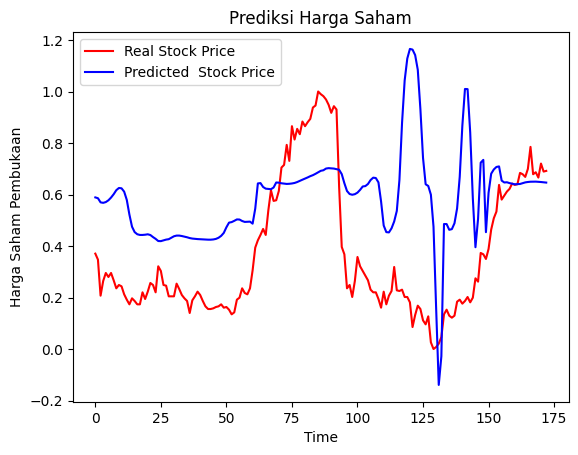

2/2 [==============================] - 0s 7ms/step
hasil prediksi harga saham:  [0.5730332136154174, 0.47965997457504267, 0.4540072381496429, 0.4528655111789703, 0.46889120340347284, 0.49536690115928644, 0.536230981349945, 0.6564868092536925, 0.8781322240829467, 1.0431665182113645, 1.128075838088989, 1.1653361320495603, 1.162738800048828, 1.1414164304733274, 1.0844784975051878, 0.9313755631446837, 0.7423660159111022, 0.6398199200630187, 0.6331692337989806, 0.5992797017097472, 0.4750888347625732, 0.1599011570215225, -0.1393332332372665, -0.02787915803492069, 0.48539945483207697, 0.48524960875511164, 0.46303305029869074, 0.46554884314537043, 0.4883745610713958, 0.5461477637290953]


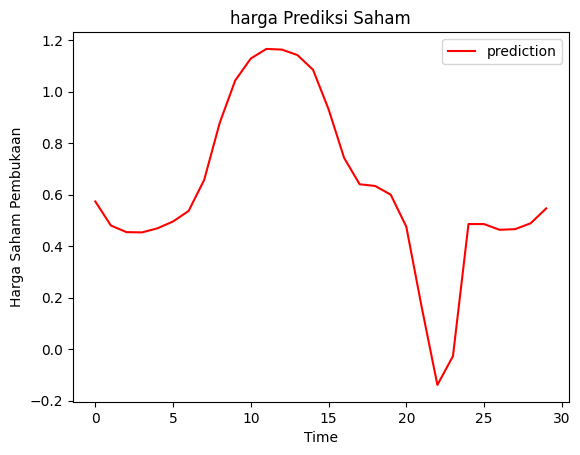

Pearson correlation:  0.29272032117363467


In [28]:
layers = [ #awalnya units=50
    LSTM(units=64, return_sequences=True),
    tfa.layers.GroupNormalization(),
    Dropout(0.2),
    LSTM(units=64, return_sequences=True),
    tfa.layers.GroupNormalization(),
    Dropout(0.2),
    LSTM(units=64),
    tfa.layers.GroupNormalization(),
    Dropout(0.2),
    Dense(units=1)
]
name = 'lstm'
epochs = 10
batch_size = 32

# Training the model.
model = rnn_model.build_model(input_shape, layers)
model, history = rnn_model.train(model, name, x_train, y_train, epochs=epochs, batch_size=batch_size)

# Making predictions.
y_predict = model.predict(x_test)

# Visualising the prediction.
stocks.plot_prediction(y_test, y_predict, 'Real Stock Price', 'Predicted  Stock Price')

results = []
frame_size = 64
n_data = x_test.shape[0]
data = x_test[(n_data - frame_size):n_data]

results = []
for i in range(0,30):
    x = model.predict(data[i:frame_size+i])
    results.append(x[0][0])
    np.append(data,x[0][0])
print("hasil prediksi harga saham: ", results)

plt.plot(results, color='red', label="prediction")
plt.title('harga Prediksi Saham')
plt.xlabel('Time')
plt.ylabel('Harga Saham Pembukaan')
plt.legend()
plt.show()

x = []
y = []
for i in range(0,y_predict.shape[0]):
    x.append(y_predict[i][0])
    y.append(y_test[i][0])
print("Pearson correlation: ", stats.pearsonr(x, y).statistic)

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_6 (Bidirecti  (None, 64, 128)           27264     
 onal)                                                           
                                                                 
 group_normalization_18 (Gr  (None, 64, 128)           256       
 oupNormalization)                                               
                                                                 
 dropout_18 (Dropout)        (None, 64, 128)           0         
                                                                 
 bidirectional_7 (Bidirecti  (None, 64, 128)           74496     
 onal)                                                           
                                                                 
 group_normalization_19 (Gr  (None, 64, 128)           256       
 oupNormalization)                                    

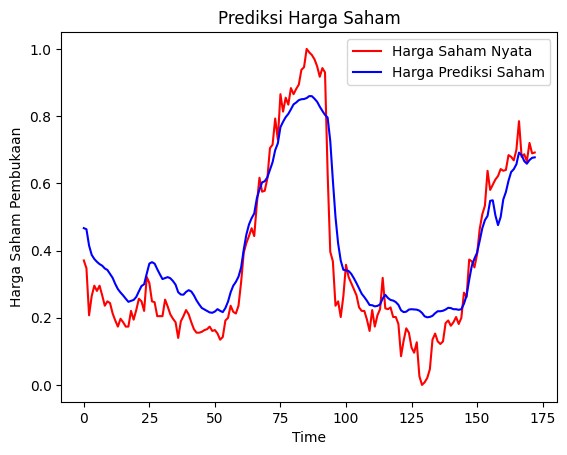

Jumlah data set:  173
jumlah row data untuk predict:  64
2/2 [==============================] - 0s 24ms/step
hasil prediksi saham:  [[0.23785241]
 [0.23716742]
 [0.23378065]
 [0.23522685]
 [0.23943827]
 [0.25734398]
 [0.2680971 ]
 [0.2587915 ]
 [0.25287908]
 [0.25106698]
 [0.24652946]
 [0.2383046 ]
 [0.22201909]
 [0.21664   ]
 [0.21799831]
 [0.22429417]
 [0.22529069]
 [0.22465172]
 [0.22400865]
 [0.22107506]
 [0.21440966]
 [0.2041564 ]
 [0.2012461 ]
 [0.20241825]
 [0.20565857]
 [0.2133766 ]
 [0.21931225]
 [0.21929549]
 [0.22072692]
 [0.22436441]
 [0.22953403]
 [0.22870162]
 [0.2253297 ]
 [0.22534408]
 [0.22349048]
 [0.22543482]
 [0.24154928]
 [0.2656458 ]
 [0.31272274]
 [0.35461488]
 [0.3760273 ]
 [0.39339262]
 [0.4286665 ]
 [0.46634126]
 [0.4904487 ]
 [0.5030352 ]
 [0.5478836 ]
 [0.5494635 ]
 [0.50461525]
 [0.47556788]
 [0.4996683 ]
 [0.5518568 ]
 [0.5741914 ]
 [0.60766256]
 [0.6337216 ]
 [0.6420332 ]
 [0.65652597]
 [0.6914614 ]
 [0.6835489 ]
 [0.6662072 ]
 [0.6583628 ]
 [0.6693115 ]


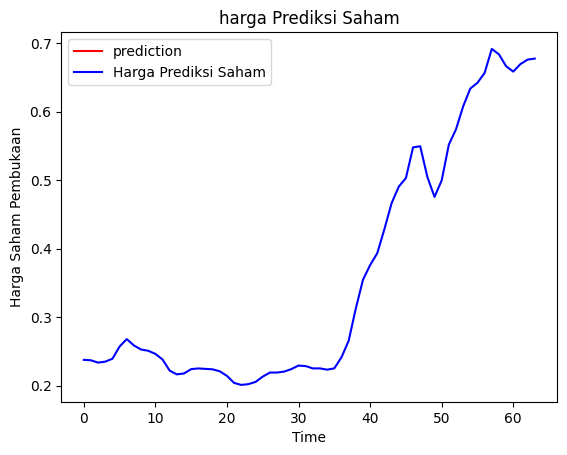

Pearson correlation:  0.9646374087322012


In [14]:
layers = [
    Bidirectional(GRU(units=64, return_sequences=True)),
    tfa.layers.GroupNormalization(),
    Dropout(0.2),
    Bidirectional(GRU(units=64, return_sequences=True)),
    tfa.layers.GroupNormalization(),
    Dropout(0.2),
    Bidirectional(LSTM(units=64)),
    tfa.layers.GroupNormalization(),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
]

name = 'bgru_lstm'
epochs = 100
batch_size = 32

# Training the model.
model = rnn_model.build_model(input_shape, layers)
#model, history = rnn_model.train(model, name, x_train, y_train, epochs=epochs, batch_size=batch_size)
model.load_weights("weights/bgru_lstm_callback.h5")
# Making predictions.
y_predict = model.predict(x_test)
print("jumlah y_predict: ",y_predict.shape[0])
print("y_test: ",y_test.shape[0])
# Visualising the prediction.
stocks.plot_prediction(y_test, y_predict, 'Harga Saham Nyata', 'Harga Prediksi Saham')

results = []
frame_size = 64
n_data = x_test.shape[0]
print("Jumlah data set: ", n_data)
data = x_test[(n_data - frame_size):n_data]
print("jumlah row data untuk predict: ",data.shape[0])
x = model.predict(data)

#print(data)
'''
results = []
for i in range(0,30):
    x = model.predict(data[i:frame_size+i])
    #print(x)
    results.append(x)
    #np.append(data,x[0][0])
'''
print("hasil prediksi saham: ", x)
prediction_label = 'Harga Prediksi Saham'
plt.plot(results, color='red', label="prediction")
plt.title('harga Prediksi Saham')
plt.xlabel('Time')
plt.ylabel('Harga Saham Pembukaan')
plt.plot(x, color='blue', label=prediction_label)
plt.legend()
plt.show()

x = []
y = []
for i in range(0,y_predict.shape[0]):
    x.append(y_predict[i][0])
    y.append(y_test[i][0])
print("Pearson correlation: ", stats.pearsonr(x, y).statistic)